# W4 — COS pricing check

This notebook checks the first COS pricing prototype for VIX options.

The code is stored in:

- `src/models/cir.py`
- `src/pricing/vix_cos.py`

The goal here is not full market calibration yet. The goal is to check that the COS prototype runs, produces non-negative VIX call and put prices, and can be compared with the W3 Monte Carlo result.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.cir import (
    CIRParams,
    cir_terminal_moments,
    cir_truncation_interval,
    vix_affine_coefficients,
    vix_level_from_variance,
)

from src.pricing.vix_cos import (
    COSSettings,
    compare_vix_call_cos_with_mc,
    price_vix_call_cos,
    price_vix_put_cos,
)

In [2]:
params = CIRParams(
    v0=0.04,
    kappa=2.0,
    theta=0.04,
    sigma_v=0.5,
)

settings = COSSettings(
    n_terms=128,
    truncation_std_width=8.0,
    coefficient_grid_size=4096,
)

option_maturity = 30 / 365
r = 0.03
delta = 30 / 365

params, settings

(CIRParams(v0=0.04, kappa=2.0, theta=0.04, sigma_v=0.5),
 COSSettings(n_terms=128, truncation_std_width=8.0, coefficient_grid_size=4096))

In [3]:
a, b = vix_affine_coefficients(
    params=params,
    delta=delta,
)

mean_v, var_v = cir_terminal_moments(
    params=params,
    maturity=option_maturity,
)

lower, upper = cir_truncation_interval(
    params=params,
    maturity=option_maturity,
    std_width=settings.truncation_std_width,
)

setup_table = pd.DataFrame(
    [
        {
            "A coefficient": a,
            "B coefficient": b,
            "E[v_T]": mean_v,
            "Var[v_T]": var_v,
            "lower truncation": lower,
            "upper truncation": upper,
            "VIX at theta": vix_level_from_variance(params.theta, params, delta),
        }
    ]
)

setup_table

,A coefficient,B coefficient,E[v_T],Var[v_T],lower truncation,upper truncation,VIX at theta
0,0.003115,0.922133,0.04,0.0007,0.0,0.251732,20.0


In [4]:
call_result = price_vix_call_cos(
    params=params,
    option_maturity=option_maturity,
    strike=20.0,
    r=r,
    delta=delta,
    settings=settings,
)

put_result = price_vix_put_cos(
    params=params,
    option_maturity=option_maturity,
    strike=20.0,
    r=r,
    delta=delta,
    settings=settings,
)

pd.DataFrame([call_result | put_result])

,vix_call_cos_price,expected_payoff,strike,lower_truncation,upper_truncation,n_terms,vix_put_cos_price
0,2.008969,2.956917,20.0,0.0,0.251732,128,2.949635


In [5]:
w3_mc_vix_call_price = 1.984952

comparison = compare_vix_call_cos_with_mc(
    cos_price=call_result["vix_call_cos_price"],
    mc_price=w3_mc_vix_call_price,
)

pd.DataFrame([comparison])

,cos_price,mc_price,absolute_difference,relative_difference
0,2.008969,1.984952,0.024017,0.0121


In [6]:
strikes = [10, 15, 20, 25, 30, 35, 40]

rows = []

for strike in strikes:
    call = price_vix_call_cos(
        params=params,
        option_maturity=option_maturity,
        strike=float(strike),
        r=r,
        delta=delta,
        settings=settings,
    )

    put = price_vix_put_cos(
        params=params,
        option_maturity=option_maturity,
        strike=float(strike),
        r=r,
        delta=delta,
        settings=settings,
    )

    rows.append(
        {
            "strike": strike,
            "call_cos_price": call["vix_call_cos_price"],
            "put_cos_price": put["vix_put_cos_price"],
        }
    )

strike_table = pd.DataFrame(rows)
strike_table

,strike,call_cos_price,put_cos_price
0,10,9.158711,0.124004
1,15,4.932858,0.885837
2,20,2.008969,2.949635
3,25,0.571070,6.499422
4,30,0.106450,11.022488
5,35,0.012447,15.916172
6,40,0.000881,20.892292


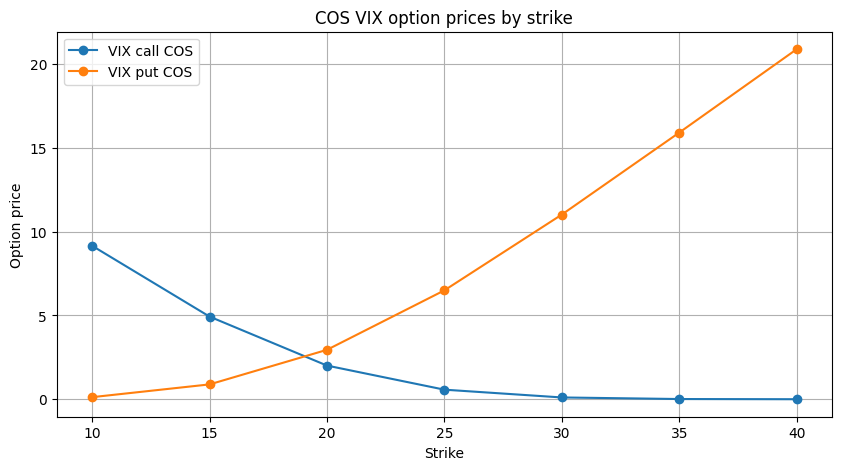

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(
    strike_table["strike"],
    strike_table["call_cos_price"],
    marker="o",
    label="VIX call COS",
)

plt.plot(
    strike_table["strike"],
    strike_table["put_cos_price"],
    marker="o",
    label="VIX put COS",
)

plt.title("COS VIX option prices by strike")
plt.xlabel("Strike")
plt.ylabel("Option price")
plt.grid(True)
plt.legend()
plt.show()

## Short note

The COS prototype produces VIX call and put prices using the terminal CIR variance distribution.

The W3 Monte Carlo result is used as the first benchmark for the VIX call price. At this stage, the goal is to check numerical behaviour and consistency, not final market calibration.

The final version can later be improved by using closed-form COS payoff coefficients, calibration to market data, and a more detailed comparison with Monte Carlo.